# Bermuda sea-level rise practical — Python rewrite

This notebook is a Python/Jupyter rewrite of `SeaLevelPractical.m`. It retains the four main analyses:

1. visualise the Bermuda tide-gauge record over different time scales;
2. use harmonic analysis to estimate and remove the astronomical tide;
3. estimate the long-term relative sea-level trend;
4. estimate the steric contribution from BATS temperature/salinity profiles and compare it with the tide-gauge trend.

The emphasis is on understanding the analysis rather than reproducing MATLAB output pixel-for-pixel. The notebook is written for advanced oceanography undergraduates and deliberately exposes the main analysis choices as editable variables.

### Environment

Create the supplied conda environment before running the notebook:

```bash
conda env create -f environment.yml
conda activate bermuda
jupyter lab
```

Python **3.13** is specified rather than 3.14 because the current UTide package metadata explicitly advertises support through Python 3.13. The other main scientific dependency, GSW-Python, supports Python 3.14, so moving the environment to 3.14 later should be straightforward once UTide formally supports it.

### Data location

The notebook searches for the original directory layout in the current directory and in a nearby `SLprac/` directory. Thus it works if it is either placed inside the extracted practical folder or one directory above it.

The current loaders understand the MATLAB `.mat` files supplied with the archive. When newer tide-gauge and BATS data are added, only the loader/configuration cells should need changing if the new files have a different format.

## Imports and helper functions

`UTide` is the Python reimplementation of the MATLAB UTide package used by the original practical. `gsw` is the maintained Python interface to TEOS-10.

In [1]:
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.io import loadmat
from scipy.stats import linregress, t as student_t

try:
    from utide import solve, reconstruct
except ImportError as exc:
    raise ImportError(
        "UTide is required. Create/activate the supplied conda environment first."
    ) from exc

# GSW is only required in Section 4. Import it here so an installation problem
# is detected early, but keep the message specific.
try:
    import gsw
except ImportError as exc:
    raise ImportError(
        "GSW-Python is required for Section 4. Create/activate the supplied conda environment first."
    ) from exc

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

for package in ["numpy", "pandas", "scipy", "matplotlib", "utide", "gsw"]:
    try:
        print(f"{package:10s} {version(package)}")
    except PackageNotFoundError:
        pass

numpy      2.5.2
pandas     3.0.5
scipy      1.18.0
matplotlib 3.11.1
utide      0.3.1
gsw        3.6.23


In [2]:
# Approximate geographic coordinates used by the analyses.
# UTide only requires latitude; TEOS-10 salinity conversion requires both.
TIDE_GAUGE_LAT = 32.37
BATS_LAT = 31.67
BATS_LON = -64.17


def locate_practical_file(relative_path):
    """Find a file in the original practical directory layout."""
    relative_path = Path(relative_path)
    candidates = [
        Path.cwd() / relative_path,
        Path.cwd() / "SLprac" / relative_path,
        Path.cwd().parent / "SLprac" / relative_path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    searched = "\n".join(f"  - {p}" for p in candidates)
    raise FileNotFoundError(f"Could not find {relative_path}. Searched:\n{searched}")


def matlab_datenum_to_datetime(datenum):
    """Convert MATLAB serial datenums to a pandas DatetimeIndex."""
    datenum = np.asarray(datenum, dtype=float)
    # MATLAB datenum 719529 corresponds to 1970-01-01.
    return pd.DatetimeIndex(
        pd.to_datetime(datenum - 719529.0, unit="D", origin="unix")
    ).round("s")


def load_tide_gauge(path):
    """Load the supplied WLData matrix and return an hourly pandas Series."""
    mat = loadmat(path)
    wl = np.asarray(mat["WLData"], dtype=float)
    time = matlab_datenum_to_datetime(wl[:, 0]).round("h")
    series = pd.Series(wl[:, 1], index=time, name="sea_level_m").sort_index()
    if series.index.has_duplicates:
        series = series.groupby(level=0).mean()
    return series


def load_bats_ts(path):
    """Load the supplied MATLAB TS structure into NumPy arrays."""
    mat = loadmat(path, squeeze_me=True, struct_as_record=False)
    ts = mat["TS"]
    return {
        "time": matlab_datenum_to_datetime(ts.Time),
        "temperature": np.asarray(ts.Temp, dtype=float),
        "salinity": np.asarray(ts.Sal, dtype=float),
        "pressure": np.asarray(ts.Pres, dtype=float),
    }


def format_date_axis(ax):
    locator = mdates.AutoDateLocator(minticks=4, maxticks=9)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))


def decimal_year(index):
    """Convert datetime values to decimal years for regression."""
    index = pd.DatetimeIndex(index)
    year_start = pd.to_datetime(index.year.astype(str) + "-01-01")
    next_start = pd.to_datetime((index.year + 1).astype(str) + "-01-01")
    return index.year + (index - year_start) / (next_start - year_start)


def annual_mean_hourly(series, min_coverage=0.50):
    """
    Annual means from an hourly sea-level series.

    Years with less than `min_coverage` of possible hourly observations are
    excluded so that a short fragment of a year is not treated as an annual mean.
    """
    means = series.resample("YS").mean()
    counts = series.resample("YS").count()
    hours_expected = pd.Series(
        np.where(means.index.is_leap_year, 366 * 24, 365 * 24),
        index=means.index,
    )
    coverage = counts / hours_expected
    return means.where(coverage >= min_coverage), coverage


def fit_linear_trend(annual_series, start=None, end=None, confidence=0.95):
    """
    Fit y = intercept + slope * year to annual means.

    The confidence interval is the conventional Student-t interval on the OLS
    slope. Annual averaging greatly reduces tidal/weather autocorrelation, but
    the interval still assumes independent regression residuals.
    """
    data = annual_series.dropna().copy()
    if start is not None:
        data = data.loc[pd.Timestamp(start):]
    if end is not None:
        data = data.loc[:pd.Timestamp(end)]
    if len(data) < 3:
        raise ValueError("At least three annual means are required for a trend.")

    x = np.asarray(decimal_year(data.index), dtype=float)
    y = data.to_numpy(dtype=float)
    result = linregress(x, y)
    dof = len(data) - 2
    critical = student_t.ppf(0.5 + confidence / 2, dof)
    slope_half_width = critical * result.stderr

    fitted = pd.Series(result.intercept + result.slope * x, index=data.index)
    return {
        "data": data,
        "fitted": fitted,
        "slope_m_per_year": result.slope,
        "slope_mm_per_year": result.slope * 1000,
        "slope_ci_half_mm_per_year": slope_half_width * 1000,
        "intercept": result.intercept,
        "r_squared": result.rvalue ** 2,
        "n_years": len(data),
        "confidence": confidence,
    }

## Load the supplied data

The archived tide-gauge record runs from 1932 to 2012. The BATS processed file contains hydrographic profiles from 1955 to 2011. Newer files can later be substituted in the two path variables below.

In [3]:
TIDE_GAUGE_FILE = locate_practical_file(
    "processed_data/Tide_Gauge_Data/Hourly_Height_Verified_Water_Level.mat"
)
BATS_TS_FILE = locate_practical_file(
    "processed_data/TS_Data/BATS_TS_DATA_1955_2010.mat"
)

tg = load_tide_gauge(TIDE_GAUGE_FILE)
print(f"Tide gauge: {tg.index.min()} to {tg.index.max()}")
print(f"Hourly samples: {len(tg):,}; valid: {tg.notna().sum():,}; missing: {tg.isna().sum():,}")
print(f"BATS file: {BATS_TS_FILE}")

Tide gauge: 1932-01-01 00:00:00 to 2012-12-31 23:00:00
Hourly samples: 613,656; valid: 525,701; missing: 87,955
BATS file: /home/nvogt/Documents/Teaching/SeaLevelPractical_Python/processed_data/TS_Data/BATS_TS_DATA_1955_2010.mat


# Section 1 — Visualising the Bermuda tide-gauge record

The same sea-level record looks very different depending on the time scale. At a few days the astronomical tide dominates; over weeks spring-neap modulation becomes obvious; at seasonal to decadal scales weather, ocean circulation, seasonal steric variability, data gaps and long-term sea-level change become important.

Change the two dates below and compare approximately **5 days, 20 days, 1 year, 10 years and the full record**.

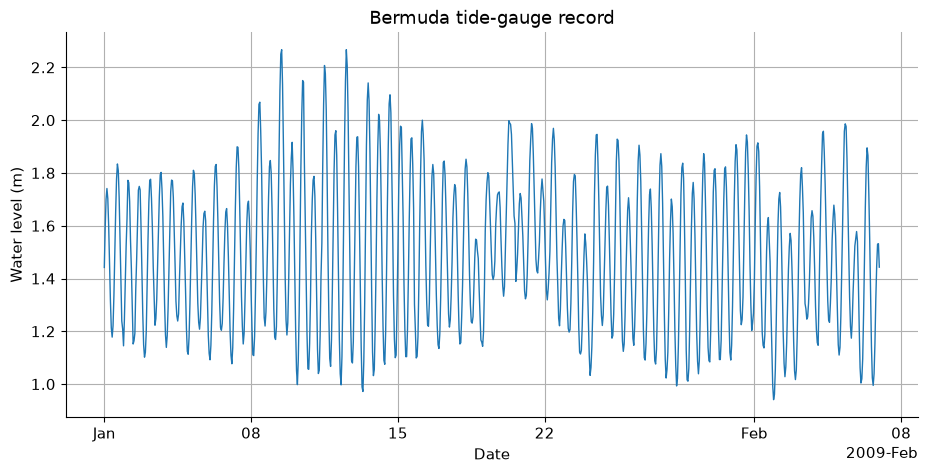

In [6]:
PLOT_START = "2009-01-01"
PLOT_END = "2009-02-06"

view = tg.loc[PLOT_START:PLOT_END]

fig, ax = plt.subplots()
ax.plot(view.index, view, lw=1)
ax.set(xlabel="Date", ylabel="Water level (m)", title="Bermuda tide-gauge record")
format_date_axis(ax)
plt.show()

### Questions

- Which periodicities can be identified by eye at each time scale?
- Why does the tidal range vary over a few weeks?
- What processes can change sea level at periods longer than the astronomical tides?
- Where are the major data gaps, and why must they be treated as gaps in **time**, not merely ignored as missing array elements?

# Section 2 — Harmonic tidal analysis and detiding

A harmonic tidal analysis represents sea level as a sum of sinusoids at known astronomical frequencies. UTide solves for the amplitude and phase of those constituents by least squares.

The original practical disabled nodal/satellite corrections. This rewrite enables UTide's nodal corrections by default. This is more appropriate when coefficients are estimated from long records because several constituents are modulated over the 18.6-year lunar nodal cycle.

Begin with a few constituents, inspect the residual, then add more constituents or use `"auto"`. Short analyses cannot resolve arbitrarily close frequencies: the record length sets the frequency resolution.

In [7]:
HARMON_START = "1941-01-01"
HARMON_END = "1941-07-01"
PLOT_START = "1941-01-01"
PLOT_END = "1941-01-31"

# Try, for example:
# ["M2", "S2", "N2", "K1"]
# ["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"]
# "auto"
HARMON_CONSTITUENTS = ["M2", "S2", "N2", "K1"]

analysis = tg.loc[HARMON_START:HARMON_END].dropna()
if not (pd.Timestamp(HARMON_START) <= pd.Timestamp(PLOT_START) <= pd.Timestamp(HARMON_END)):
    raise ValueError("PLOT_START must fall inside the harmonic-analysis interval.")
if not (pd.Timestamp(HARMON_START) <= pd.Timestamp(PLOT_END) <= pd.Timestamp(HARMON_END)):
    raise ValueError("PLOT_END must fall inside the harmonic-analysis interval.")

coef = solve(
    analysis.index.to_numpy(),
    analysis.to_numpy(),
    lat=TIDE_GAUGE_LAT,
    constit=HARMON_CONSTITUENTS,
    trend=False,          # do not allow the tidal fit to absorb secular sea-level rise
    nodal=True,
    method="ols",
    conf_int="linear",
    Rayleigh_min=1.0,
    verbose=False,
)

# Supplying the constituent names explicitly reconstructs all solved constituents.
reconstructed = reconstruct(
    analysis.index.to_numpy(),
    coef,
    constit=list(coef.name),
    verbose=False,
).h

section2 = pd.DataFrame(
    {
        "observed": analysis.to_numpy(),
        "synthetic_tide": reconstructed,
        "detided": analysis.to_numpy() - reconstructed,
    },
    index=analysis.index,
)

constituent_table = pd.DataFrame({
    "constituent": coef.name,
    "amplitude_m": coef.A,
    "amplitude_95pc_halfwidth_m": coef.A_ci,
    "greenwich_phase_deg": coef.g,
    "phase_95pc_halfwidth_deg": coef.g_ci,
})
constituent_table

,constituent,amplitude_m,amplitude_95pc_halfwidth_m,greenwich_phase_deg,phase_95pc_halfwidth_deg
0,M2,0.369809,0.004367,358.393527,0.676351
1,S2,0.090053,0.004366,27.891182,2.777988
2,N2,0.083013,0.004365,342.983293,3.013962
3,K1,0.063379,0.006337,190.948197,5.721079


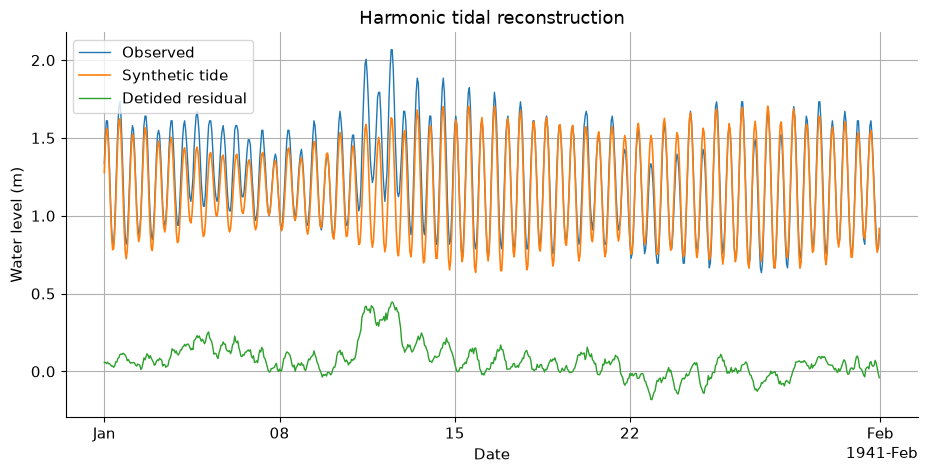

In [8]:
plot_data = section2.loc[PLOT_START:PLOT_END]
fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["observed"], label="Observed", lw=1)
ax.plot(plot_data.index, plot_data["synthetic_tide"], label="Synthetic tide", lw=1.2)
ax.plot(plot_data.index, plot_data["detided"], label="Detided residual", lw=1)
ax.set(xlabel="Date", ylabel="Water level (m)", title="Harmonic tidal reconstruction")
format_date_axis(ax)
ax.legend()
plt.show()

### Questions

- How does the residual change when only M2 and S2 are fitted? What changes after adding N2, K2, K1, O1, P1 and Q1?
- Does a constituent list that works for a one-month plot also remove the tide satisfactorily over several months?
- How does the inferred amplitude/phase change when the harmonic-analysis interval is lengthened?
- Why can two close frequencies be difficult to distinguish in a short record?
- UTide reports Greenwich-referenced phases. Compare the dominant constituent amplitudes and phases with an authoritative tidal-constituent table for the station, remembering that datum conventions, analysis interval and nodal treatment can produce differences.

# Section 3 — Long-term relative sea-level trend

The MATLAB practical avoided a full-record harmonic fit because of laptop memory limits. It instead loaded a synthetic tide produced from a five-year analysis in a chosen decade and applied that tide to the entire record.

Here the harmonic fit is performed directly on **all valid tide-gauge observations**. A fixed set of the eight major diurnal and semidiurnal constituents is used by default to keep the computational cost predictable even when the record is extended to the present. The list can be expanded if residual tidal energy remains important.

The fitted tidal model excludes a secular trend, so the tidal regression cannot remove the long-term sea-level trend itself.

In [9]:
FULL_RECORD_CONSTITUENTS = ["M2", "S2", "N2", "K2", "K1", "O1", "P1", "Q1"]
SMOOTH_WINDOW_DAYS = 30
TREND_START = None   # e.g. "1950-01-01"; None uses the first usable year
TREND_END = None     # e.g. "2012-12-31"; None uses the last usable year
CONFIDENCE = 0.95
MIN_ANNUAL_COVERAGE = 0.50

valid_tg = tg.dropna()
print(f"Fitting {len(FULL_RECORD_CONSTITUENTS)} constituents to {len(valid_tg):,} valid observations...")

coef_full = solve(
    valid_tg.index.to_numpy(),
    valid_tg.to_numpy(),
    lat=TIDE_GAUGE_LAT,
    constit=FULL_RECORD_CONSTITUENTS,
    trend=False,
    nodal=True,
    method="ols",
    conf_int="none",     # faster for the long fit; Section 2 demonstrates constituent CIs
    verbose=False,
)

full_tide = reconstruct(
    tg.index.to_numpy(),
    coef_full,
    constit=FULL_RECORD_CONSTITUENTS,
    verbose=False,
).h

# UTide's reconstruction includes the fitted mean. Remove only the tidal anomaly
# so that the tide-gauge datum/mean level remains in the detided record.
tidal_anomaly = full_tide - np.nanmean(full_tide)
detided_tg = pd.Series(tg.to_numpy() - tidal_anomaly, index=tg.index, name="detided_m")

# A time-based rolling window respects actual time gaps. It does not concatenate
# samples on opposite sides of a long gap as the original MATLAB filtering kludge did.
smoothed_tg = detided_tg.rolling(
    f"{SMOOTH_WINDOW_DAYS}D", center=True, min_periods=1
).mean()

annual_tg, annual_coverage = annual_mean_hourly(detided_tg, MIN_ANNUAL_COVERAGE)
tg_trend = fit_linear_trend(
    annual_tg,
    start=TREND_START,
    end=TREND_END,
    confidence=CONFIDENCE,
)

print(
    f"Relative sea-level trend = {tg_trend['slope_mm_per_year']:.2f} ± "
    f"{tg_trend['slope_ci_half_mm_per_year']:.2f} mm/yr "
    f"({CONFIDENCE:.0%} OLS slope CI; n={tg_trend['n_years']} annual means)"
)
print(f"R² = {tg_trend['r_squared']:.3f}")

Fitting 8 constituents to 525,701 valid observations...
Relative sea-level trend = 2.03 ± 0.53 mm/yr (95% OLS slope CI; n=62 annual means)
R² = 0.497


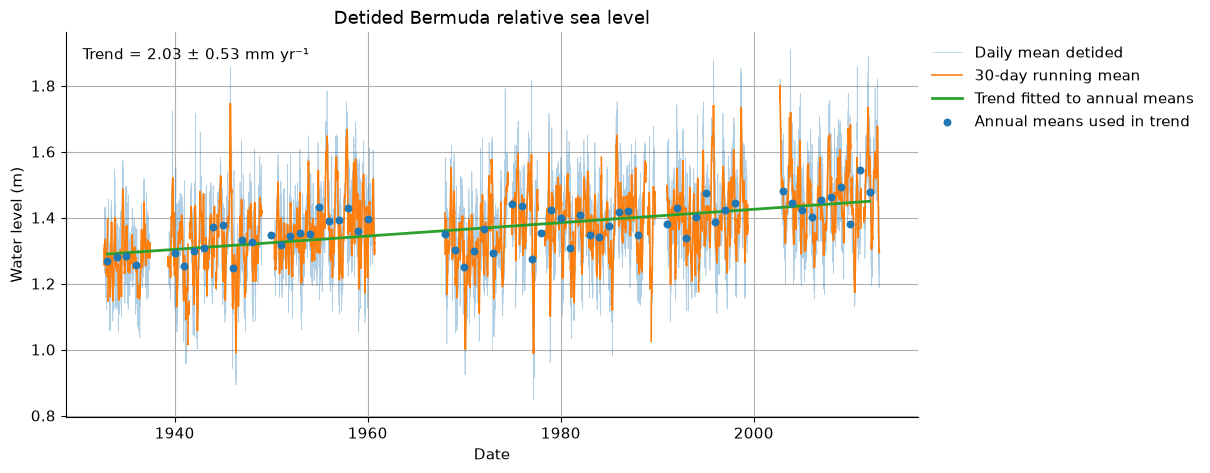

In [15]:
# Daily means are used only for plotting the noisy residual efficiently;
# the harmonic analysis above used every valid observation.
daily_detided = detided_tg.resample("D").mean()

fig, ax = plt.subplots()
ax.plot(daily_detided.index, daily_detided, lw=0.5, alpha=0.35, label="Daily mean detided")
ax.plot(smoothed_tg.index, smoothed_tg, lw=1.2, label=f"{SMOOTH_WINDOW_DAYS}-day running mean")
ax.plot(tg_trend["fitted"].index, tg_trend["fitted"], lw=2, label="Trend fitted to annual means")
ax.scatter(tg_trend["data"].index, tg_trend["data"], s=22, zorder=4, label="Annual means used in trend")
ax.set(xlabel="Date", ylabel="Water level (m)", title="Detided Bermuda relative sea level")
format_date_axis(ax)
ax.legend(ncol=1, frameon=False, loc='upper left', bbox_to_anchor=(1,1))
ax.text(
    0.02, 0.96,
    f"Trend = {tg_trend['slope_mm_per_year']:.2f} ± {tg_trend['slope_ci_half_mm_per_year']:.2f} mm yr⁻¹",
    transform=ax.transAxes, va="top",
)
plt.show()

### Trend and uncertainty

The original MATLAB script used `polyconf(..., 'Predopt','curve')` and then labelled the mean vertical confidence-band width as an uncertainty in **mm/year**. That quantity has units of sea level, not slope, so it is not a confidence interval on the trend rate.

This notebook instead:

1. detides the full record;
2. forms annual means, excluding years with poor hourly coverage;
3. fits a straight line to those annual means; and
4. reports the Student-t confidence interval on the **slope**.

Annual averaging also avoids treating hundreds of thousands of serially correlated hourly values as independent regression observations. The resulting interval is still an OLS interval and should not be interpreted as a complete estimate of geophysical uncertainty.

### Questions

- How sensitive is the estimated trend to the start and end years?
- What happens if `MIN_ANNUAL_COVERAGE` is made more or less strict?
- Does changing the running-mean window alter the plotted variability? Should it materially alter a trend fitted to annual means?
- Expand `FULL_RECORD_CONSTITUENTS`. Does the long-term trend change appreciably? If it does, investigate why.
- Why is a tide-gauge trend a **relative** sea-level trend rather than an absolute/global mean sea-level trend?

# Section 4 — Steric sea-level contribution from BATS hydrography

Steric sea-level change results from changes in seawater density caused mainly by temperature and salinity. Following the conceptual calculation in the original practical, the steric height of a profile is estimated as

\[
\eta_s = \int \frac{\rho_{ref}-\rho}{\rho_{ref}}\,dz.
\]

The MATLAB code passed the archived salinity and temperature directly to a GSW density routine. The BATS fields are Practical Salinity and in-situ temperature, whereas modern TEOS-10 density uses **Absolute Salinity** and **Conservative Temperature**. The rewrite therefore performs the TEOS-10 conversions explicitly before calculating density.

A reference profile with Practical Salinity 35 and in-situ temperature 0 °C is converted through the same TEOS-10 pathway. Geometric layer thickness is obtained from pressure using `gsw.z_from_p`, rather than treating a pressure increment in dbar as exactly equal to a vertical distance in metres.

In [16]:
REFERENCE_SP = 35.0
REFERENCE_T_C = 0.0
MAX_PRESSURE_DBAR = 2000.0
STERIC_SMOOTH_DAYS = 180
MIN_CASTS_PER_YEAR = 3
STERIC_TREND_START = None
STERIC_TREND_END = None

bats = load_bats_ts(BATS_TS_FILE)
print(
    f"BATS profiles: {bats['time'].min()} to {bats['time'].max()} "
    f"({len(bats['time'])} processed casts)"
)


def steric_height_profile(sp, temp, pressure, lat=BATS_LAT, lon=BATS_LON):
    """Calculate steric height (m) relative to SP=35, t=0 °C down to 2000 dbar."""
    good = np.isfinite(sp) & np.isfinite(temp) & np.isfinite(pressure)
    sp = np.asarray(sp[good], dtype=float)
    temp = np.asarray(temp[good], dtype=float)
    pressure = np.asarray(pressure[good], dtype=float)

    if pressure.size < 3:
        return np.nan

    order = np.argsort(pressure)
    pressure, sp, temp = pressure[order], sp[order], temp[order]

    # Remove duplicate pressure levels before interpolation.
    pressure, unique_index = np.unique(pressure, return_index=True)
    sp, temp = sp[unique_index], temp[unique_index]

    # Require near-full column coverage. A few archived casts end slightly above
    # 2000 dbar, so allow modest endpoint interpolation/extrapolation (<=100 dbar).
    if pressure.size < 3 or pressure.min() > 20 or pressure.max() < 1900:
        return np.nan

    # Standardise every profile to exactly 0-2000 dbar. np.interp uses the
    # nearest endpoint value for the small extrapolation to 0 or 2000 dbar.
    interior = pressure[(pressure > 0) & (pressure < MAX_PRESSURE_DBAR)]
    p_grid = np.unique(np.concatenate(([0.0], interior, [MAX_PRESSURE_DBAR])))
    sp_grid = np.interp(p_grid, pressure, sp)
    t_grid = np.interp(p_grid, pressure, temp)

    # Layer-midpoint properties.
    p_mid = 0.5 * (p_grid[:-1] + p_grid[1:])
    sp_mid = 0.5 * (sp_grid[:-1] + sp_grid[1:])
    t_mid = 0.5 * (t_grid[:-1] + t_grid[1:])

    # Convert observational variables to TEOS-10 variables.
    sa = gsw.SA_from_SP(sp_mid, p_mid, lon, lat)
    ct = gsw.CT_from_t(sa, t_mid, p_mid)
    rho = gsw.rho(sa, ct, p_mid)

    # Apply the same conversion to the reference water mass.
    sp_ref = np.full_like(p_mid, REFERENCE_SP)
    t_ref = np.full_like(p_mid, REFERENCE_T_C)
    sa_ref = gsw.SA_from_SP(sp_ref, p_mid, lon, lat)
    ct_ref = gsw.CT_from_t(sa_ref, t_ref, p_mid)
    rho_ref = gsw.rho(sa_ref, ct_ref, p_mid)

    # gsw.z_from_p returns height relative to sea level (negative below sea level).
    z = gsw.z_from_p(p_grid, lat)
    dz = np.abs(np.diff(z))

    return np.sum((rho_ref - rho) / rho_ref * dz)


steric_values = np.array([
    steric_height_profile(
        bats["salinity"][:, i],
        bats["temperature"][:, i],
        bats["pressure"][:, i],
    )
    for i in range(len(bats["time"]))
])

steric = pd.Series(steric_values, index=bats["time"], name="steric_height_m").sort_index()
steric_smooth = steric.rolling(
    f"{STERIC_SMOOTH_DAYS}D", center=True, min_periods=1
).mean()

steric_annual = steric.resample("YS").mean()
steric_cast_count = steric.resample("YS").count()
steric_annual = steric_annual.where(steric_cast_count >= MIN_CASTS_PER_YEAR)

print(f"Valid steric-height estimates: {steric.notna().sum()} / {len(steric)} profiles")

BATS profiles: 1955-03-10 16:17:02 to 2011-12-11 06:57:36 (731 processed casts)
Valid steric-height estimates: 725 / 731 profiles


## Compare steric and tide-gauge trends over the same years

The original Section 4 fitted the steric trend over the requested hydrographic interval but then recalculated the tide-gauge trend over its complete record. A ratio of those two slopes does not compare like with like.

Here the two annual series are aligned and the regressions use exactly the years for which **both** estimates exist. Optional start/end dates can then restrict that common period further.

In [17]:
comparison = pd.concat(
    [annual_tg.rename("relative_sea_level_m"), steric_annual.rename("steric_height_m")],
    axis=1,
).dropna()

if STERIC_TREND_START is not None:
    comparison = comparison.loc[pd.Timestamp(STERIC_TREND_START):]
if STERIC_TREND_END is not None:
    comparison = comparison.loc[:pd.Timestamp(STERIC_TREND_END)]

if len(comparison) < 3:
    raise ValueError("Too few common annual values to compare tide-gauge and steric trends.")

common_tg_trend = fit_linear_trend(
    comparison["relative_sea_level_m"], confidence=CONFIDENCE
)
common_steric_trend = fit_linear_trend(
    comparison["steric_height_m"], confidence=CONFIDENCE
)

steric_fraction_percent = (
    100 * common_steric_trend["slope_mm_per_year"] / common_tg_trend["slope_mm_per_year"]
)

print(
    f"Common comparison years: {comparison.index.min().year}–{comparison.index.max().year} "
    f"({len(comparison)} years)"
)
print(
    f"Tide-gauge trend: {common_tg_trend['slope_mm_per_year']:.2f} ± "
    f"{common_tg_trend['slope_ci_half_mm_per_year']:.2f} mm/yr"
)
print(
    f"Steric trend:     {common_steric_trend['slope_mm_per_year']:.2f} ± "
    f"{common_steric_trend['slope_ci_half_mm_per_year']:.2f} mm/yr"
)
print(f"Steric trend / relative sea-level trend = {steric_fraction_percent:.1f}%")

Common comparison years: 1955–2011 (36 years)
Tide-gauge trend: 1.77 ± 1.10 mm/yr
Steric trend:     0.86 ± 1.14 mm/yr
Steric trend / relative sea-level trend = 48.9%


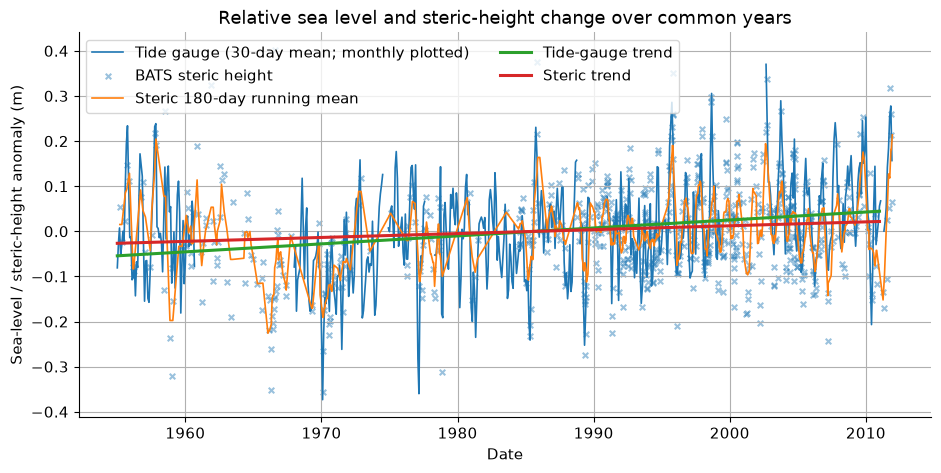

In [18]:
# Centre each curve on its mean over the comparison interval so the plot emphasises
# variability and slope rather than arbitrary vertical reference levels.
start_common = comparison.index.min()
end_common = comparison.index.max() + pd.offsets.YearEnd(0)

tg_monthly_plot = smoothed_tg.resample("MS").mean().loc[start_common:end_common]
steric_plot = steric.loc[start_common:end_common]
steric_smooth_plot = steric_smooth.loc[start_common:end_common]

tg_center = tg_monthly_plot.mean()
steric_center = steric_plot.mean()

fig, ax = plt.subplots()
ax.plot(
    tg_monthly_plot.index,
    tg_monthly_plot - tg_center,
    lw=1.2,
    label=f"Tide gauge ({SMOOTH_WINDOW_DAYS}-day mean; monthly plotted)",
)
ax.scatter(
    steric_plot.index,
    steric_plot - steric_center,
    s=16,
    alpha=0.45,
    marker="x",
    label="BATS steric height",
)
ax.plot(
    steric_smooth_plot.index,
    steric_smooth_plot - steric_center,
    lw=1.2,
    label=f"Steric {STERIC_SMOOTH_DAYS}-day running mean",
)

# Trend lines, mean-centred independently.
tg_fit_plot = common_tg_trend["fitted"] - common_tg_trend["fitted"].mean()
sh_fit_plot = common_steric_trend["fitted"] - common_steric_trend["fitted"].mean()
ax.plot(tg_fit_plot.index, tg_fit_plot, lw=2.2, label="Tide-gauge trend")
ax.plot(sh_fit_plot.index, sh_fit_plot, lw=2.2, label="Steric trend")

ax.set(
    xlabel="Date",
    ylabel="Sea-level / steric-height anomaly (m)",
    title="Relative sea level and steric-height change over common years",
)
format_date_axis(ax)
ax.legend(ncol=2)
plt.show()

### Questions

- What fraction of the observed relative sea-level trend is associated with the estimated steric trend over the common period?
- How does that fraction change if the comparison starts later or ends earlier?
- Why should the remainder **not** automatically be interpreted as glacier/ice-sheet mass addition alone? Consider vertical land motion, ocean mass, atmospheric loading, regional circulation/dynamic sea level, freshwater effects, unresolved deep-ocean steric change, and sampling uncertainty.
- How sensitive is the steric trend to the smoothing window and the minimum number of casts required per year?
- The hydrographic calculation integrates only to 2000 dbar. What signal would be missed if the deep ocean below 2000 dbar warms or freshens?

# Substantive changes from the MATLAB practical

The following changes can affect the scientific result or its interpretation; purely syntactic MATLAB-to-Python changes are not listed.

1. **Python 3.13 is used instead of 3.14 for the supplied environment.** Current UTide package metadata explicitly lists Python support through 3.13, so 3.13 is the conservative reproducible choice. The notebook itself does not depend on Python-3.13-only syntax.
2. **Python UTide replaces MATLAB UTide.** This is a reimplementation of the same analysis family, but numerical details and option defaults are not guaranteed to be byte-for-byte identical.
3. **Nodal/satellite corrections are enabled.** The MATLAB call used `NodSatNone`, whereas this rewrite uses `nodal=True`. This is preferable for multi-year to multi-decadal analyses because astronomical constituent amplitudes/phases are modulated over the lunar nodal cycle.
4. **Section 3 fits the tide directly to the full valid tide-gauge record.** It no longer loads a synthetic tidal curve generated from a five-year interval in a chosen decade. This removes the original assumption that a short-period harmonic solution is stationary over the full record and meets the requirement to analyse the complete record up to the present when newer data are supplied.
5. **A fixed eight-constituent set is the default for the full-record fit.** This makes memory/time requirements predictable. Section 2 still allows `"auto"` and arbitrary constituent lists for exploration. The full-record list can be expanded if residual tidal energy is important.
6. **The running mean respects real time gaps.** Pandas time-based rolling windows replace the MATLAB filter applied after removing NaNs. The MATLAB approach compressed the time axis and could average samples that were actually separated by long data gaps.
7. **The long-term trend is fitted to annual means rather than every smoothed hourly point.** This gives years more comparable statistical weight and avoids pseudo-replication from strongly serially correlated hourly observations. Years with poor data coverage are excluded by an explicit threshold.
8. **Trend uncertainty is now a confidence interval on the regression slope.** The MATLAB script used `polyconf(..., 'Predopt','curve')` and labelled the resulting vertical curve uncertainty as mm/year. That quantity does not have slope units. The rewrite reports a Student-t OLS confidence interval on the slope in mm/year.
9. **The steric calculation uses TEOS-10 variables consistently.** Practical Salinity and in-situ temperature are converted to Absolute Salinity and Conservative Temperature with GSW before density is calculated. The reference state is converted through the same pathway.
10. **Steric integration uses geometric layer thickness.** `gsw.z_from_p` is used to convert pressure levels to vertical coordinates, rather than treating `diff(pressure)` in dbar as exactly equivalent to metres.
11. **Steric smoothing uses a centred time-based running mean.** The original used forward-looking, overlapping bins tied to profile indices. The new method is easier to interpret on irregularly sampled casts. The default window is 180 days rather than 30 days because the BATS profile series is sparse relative to the hourly tide-gauge series; students can change it.
12. **The steric and tide-gauge trends are compared over exactly the same annual samples.** The MATLAB Section 4 steric fit used the selected hydrographic interval but the tide-gauge fit was recalculated over the complete tide-gauge record. The rewrite aligns the two annual series before fitting, so their slope ratio is a like-for-like comparison.
13. **The running mean in Section 3 is applied to the detided series.** The MATLAB code calculated `DeTide` but then smoothed `TGLevel` (the raw tide-gauge record). The rewrite smooths the detided record explicitly.
14. **Steric profiles are standardised to a 0–2000 dbar column.** Small endpoint gaps are filled by interpolation/limited endpoint extrapolation; profiles not reaching at least 1900 dbar or not approaching the surface are excluded. This avoids silently integrating different depth ranges in different years.
15. **The plotted raw detided tide-gauge residual is reduced to daily means for display only.** The tidal fit still uses every valid observation. This reduces plotting overhead for records extended to the present and does not change the analysis.

### Statistical caveat

The reported OLS slope confidence intervals assume independent annual regression residuals. Annual averaging greatly reduces short-period autocorrelation but does not guarantee independence. A more advanced extension could use generalized least squares, autoregressive residual models or a block bootstrap.